# STAT 301: Individual Assignment 1

## Group 4
- Aryan Taneja (28975563)
- Dana Assali
- Sara Raheja
- Shaam Purushotam

## Planning Stage: Data Description & Exploratory Data Analysis

In [1]:
library(scales)
library(tidyverse)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Dataset Overview

This dataset contains **nutritional information for menu items** from 8 major fast food chains in the United States: McDonald's, Burger King, Taco Bell, Sonic, Arby's, Dairy Queen, Chick Fil-A, and Subway.

Each row represents a single menu item and includes macronutrient content, micronutrient percentages, and a categorical label indicating whether the item is a salad or not. The data are well-suited for comparing nutritional profiles across restaurants and analyzing dietary characteristics of fast food offerings.

## Number of Observations and Variables

In [2]:
# file_url <- "https://www.openintro.org/data/csv/fastfood.csv"
# dest_file <- "fastfood.csv"
# download.file(file_url, dest_file, method = "curl")

fastfood <- read.csv("https://www.openintro.org/data/csv/fastfood.csv")

cat("Number of observations:", nrow(fastfood), "\n")
cat("Number of variables:   ", ncol(fastfood), "\n")

Number of observations: 515 
Number of variables:    17 


## Variable Names and Types

In [3]:
# str(fastfood)

tibble(
  Variable = names(fastfood),
  Type     = map_chr(fastfood, class)
)

Variable,Type
<chr>,<chr>
restaurant,character
item,character
calories,integer
cal_fat,integer
total_fat,integer
sat_fat,numeric
trans_fat,numeric
cholesterol,integer
sodium,integer


## Data Collection Process

The collection method is not explicitly documented in the dataset. Based on its structure and content, the most plausible assumption is that the nutritional values were scraped or manually compiled from each restaurant's publicly available nutrition information (e.g., official websites or printed nutrition guides), which are required disclosures under the U.S. FDA menu-labeling regulations. 

Under this assumption:
- Each observation corresponds to one menu item as listed by the restaurant at a point in time.
- Values reflect standard/default preparation (no customization).
- The data represent a cross-sectional snapshot: menu compositions and nutritional content can change over time.
- Items may not be nationally uniform (regional menu variations may not be captured).

## Data Source and Citation

In [4]:
# Confirm restaurants represented in the dataset
cat("Restaurants in dataset:\n")
print(table(fastfood$restaurant))

Restaurants in dataset:

      Arbys Burger King Chick Fil-A Dairy Queen   Mcdonalds       Sonic 
         55          70          27          42          57          53 
     Subway   Taco Bell 
         96         115 


**Source:** This dataset is distributed via the [`openintro`](https://cran.r-project.org/package=openintro) R package and the [OpenIntro](https://www.openintro.org/) project.

**Citation:** 

- Çetinkaya-Rundel M, Diez D, Bray A, Kim A, Baumer B, Ismay C, Paterno N, Barr C (2025). openintro: Datasets and Supplemental Functions from 'OpenIntro' Textbooks and Labs. R package version 2.5.0, http://openintrostat.github.io/openintro/.

## Question

Can the sodium content of a fast food menu item be predicted from its nutritional composition (calories, fat, carbohydrates, protein, fiber), and does the relationship between calorie content and sodium differ across restaurant chains? More broadly, are certain chains systematically associated with higher sodium levels even after controlling for macronutrient content and item type?

### Prediction, Inference, or Both?

Both. From a prediction standpoint, we want a model that accurately estimates sodium content from observable nutritional characteristics. From an inference standpoint, we want to understand whether the calorie-sodium relationship is moderated by restaurant chain, that is, whether some chains use sodium differently than others at equivalent calorie levels. The interaction term `calories * restaurant` is the key inferential quantity of interest.

### Response Variable

Sodium: total sodium content in milligrams (mg). It is a continuous, positive variable and will be modeled using multiple linear regression. A log transformation may be considered if the distribution is right-skewed.

### Important Covariates

- `calories`: The primary continuous predictor. Higher calorie items tend to be larger and more processed, likely driving sodium up.
- `restaurant`: Chains captures systematic differences in recipes, processing, and seasoning.
- `calories * restaurant`: The focal interaction; we expect the calorie–sodium slope to vary by chain (e.g., Subway is known for high-sodium, relatively lower-calorie items).
- `total_fat` and `total_carb`: Macronutrients that proxy for item size and type, independently associated with sodium.

### Other Variables

- `protein` and `fiber`: Act as controls for item composition; high-protein items (grilled meats) and high-fiber items (salads, wraps) may have distinct sodium profiles independent of calories
- `sat_fat` and `trans_fat`: Partially collinear with total_fat; may be retained or excluded depending on multicollinearity diagnostics
- `vit_a`, `vit_c`, `calcium`: Micronutrient % daily values; likely weak predictors of sodium.
- `cal_fat`: Largely redundant with total_fat and calories; will monitor for multicollinearity
- `salad`: No information added to the dataset (all records have 'other')

## Exploratory Data Analysis and Visualization

### Loading the dataset

In [5]:
head(fastfood)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2,0.0,95,1110,44,3,11,37,4,20,20,Other
2,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17,1.5,130,1580,62,2,18,46,6,20,20,Other
3,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27,3.0,220,1920,63,3,18,70,10,20,50,Other
4,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10,0.5,155,1940,62,2,18,55,6,25,20,Other
5,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12,0.5,120,1980,81,4,18,46,6,20,20,Other
6,Mcdonalds,Big Mac,540,250,28,10,1.0,80,950,46,3,9,25,10,2,15,Other


### Data Cleaning and Wrangling

In [6]:
fastfood_clean <- fastfood |>

  # Fix salad: contains only 'Other' despite salad items existing.
  # Reconstruct it by detecting 'salad' in the item name.
  mutate(salad = if_else(str_detect(str_to_lower(item), "salad"), "Salad", "Other")) |>

  # Convert categorical variables to factors
  mutate(
    restaurant = factor(restaurant),
    restaurant = relevel(restaurant, ref = "Mcdonalds"),
    salad      = factor(salad, levels = c("Other", "Salad"))
  )

tail(fastfood_clean)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
,<fct>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
510,Taco Bell,Original Triple Double Crunchwrap,700,270,30,9,0.5,45,1550,85,9,7,23,15,6,25,Other
511,Taco Bell,Spicy Triple Double Crunchwrap,780,340,38,10,0.5,50,1850,87,9,8,23,20,10,25,Other
512,Taco Bell,Express Taco Salad w/ Chips,580,260,29,9,1.0,60,1270,59,8,7,23,NA,NA,NA,Salad
513,Taco Bell,Fiesta Taco Salad-Beef,780,380,42,10,1.0,60,1340,74,11,7,26,NA,NA,NA,Salad
514,Taco Bell,Fiesta Taco Salad-Chicken,720,320,35,7,0.0,70,1260,70,8,8,32,NA,NA,NA,Salad
515,Taco Bell,Fiesta Taco Salad-Steak,720,320,36,8,1.0,55,1340,70,8,8,28,NA,NA,NA,Salad


### Missing Values

In [7]:
na_counts <- colSums(is.na(fastfood_clean))
na_pct    <- round(na_counts / nrow(fastfood_clean) * 100, 1)
data.frame(n_missing = na_counts, pct_missing = na_pct) |>
    arrange(desc(pct_missing))

,n_missing,pct_missing
,<dbl>,<dbl>
vit_a,214,41.6
vit_c,210,40.8
calcium,210,40.8
fiber,12,2.3
protein,1,0.2
restaurant,0,0.0
item,0,0.0
calories,0,0.0
cal_fat,0,0.0


Three micronutrient variables, `vit_a`, `vit_c`, and `calcium`, where `vit_c` and `calcium` have approximately **40.8% missing values** and `vit_a` has approximately **41.6% missing values**, well above the 20% threshold. This is a substantial proportion and likely reflects inconsistent reporting practices across chains rather than data entry errors (some chains may not have disclosed micronutrient percentages).'

These variables should be used with caution and will play only a secondary role in modeling. All macronutrient variables (`calories`, `total_fat`, `sodium`, `protein`, etc.) have negligible or zero missingness and are reliable for analysis.

### Class Imbalance in Categorical Variables

In [8]:
print("================ restaurant ================")
fastfood_clean |>
  count(restaurant) |>
  mutate(pct = round(n / sum(n) * 100, 1)) |>
  arrange(desc(n)) |>
  print()


print("================    salad   ================")
fastfood_clean |>
  count(salad) |>
  mutate(pct = round(n / sum(n) * 100, 1)) |>
  print()

[1] "================ restaurant ================"
   restaurant   n  pct
1   Taco Bell 115 22.3
2      Subway  96 18.6
3 Burger King  70 13.6
4   Mcdonalds  57 11.1
5       Arbys  55 10.7
6       Sonic  53 10.3
7 Dairy Queen  42  8.2
8 Chick Fil-A  27  5.2
[1] "================    salad   ================"
  salad   n  pct
1 Other 451 87.6
2 Salad  64 12.4


Two sources of imbalance are present:

1. **`restaurant`**: Taco Bell (22.3%) and Subway (18.6%) together account for over 40% of all items, while Chick Fil-A has only 27 items (5.2%). This means per-chain estimates, particularly interaction slopes, will be more precise for larger chains. The imbalance is moderate and manageable in a regression context.

2. **`salad`**: Only 64 of 515 items (12.4%) are salads, making this a very imbalanced binary variable. This is important because salads tend to have atypical sodium profiles (high sodium from dressings despite lower calories), and their underrepresentation could mask or distort the calorie–sodium relationship if not accounted for explicitly in the model.

### Visualization

`geom_smooth()` using formula = 'y ~ x'


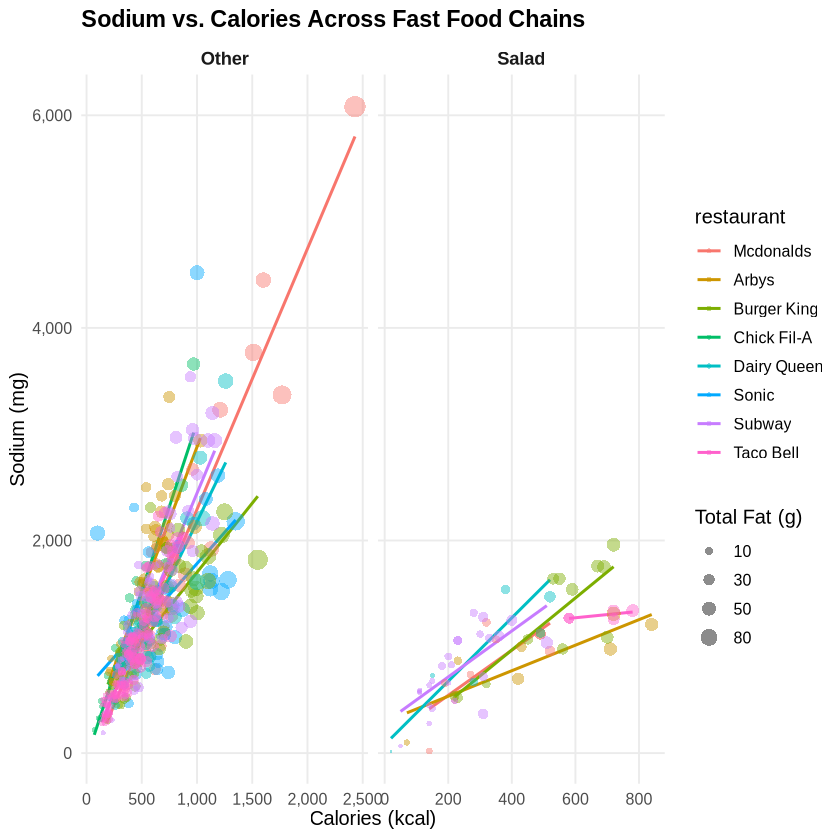

In [9]:
plot_data <- fastfood_clean |>
  filter(!is.na(sodium), !is.na(calories), !is.na(total_fat))


initial_plot <- ggplot(plot_data, aes(x = calories, y = sodium, colour = restaurant)) +

  geom_smooth(
    aes(group = restaurant),
    method  = "lm",
    se      = FALSE,
    linewidth = 0.85,
    alpha   = 0.85
  ) +

  geom_point(
    aes(size = total_fat),
    alpha = 0.45,
    stroke = 0
  ) +

  facet_wrap(~ salad, ncol = 2, scales = "free_x") +

  scale_size_continuous(
    name   = "Total Fat (g)",
    range  = c(0.8, 6),
    breaks = c(10, 30, 50, 80)
  ) +
  scale_x_continuous(labels = comma) +
  scale_y_continuous(labels = comma) +

  labs(
    title    = "Sodium vs. Calories Across Fast Food Chains",
    x        = "Calories (kcal)",
    y        = "Sodium (mg)",
  ) +

  theme_minimal(base_size = 12) +
  theme(
    plot.title      = element_text(face = "bold", size = 14),
    plot.subtitle   = element_text(colour = "grey40", size = 10),
    strip.text      = element_text(face = "bold", size = 11),
    legend.position = "right",
    panel.grid.minor = element_blank()
  )

initial_plot

### Interpretation

- **Diverging slopes:** In the non-salad panel, the per-chain regression lines diverge noticeably rather than running parallel, which supports the existence of the `calories * restaurant` interaction term. McDonald's stands out most dramatically, since its slope is considerably steeper than all other chains, suggesting that as calorie content increases, sodium rises much faster for McDonald's items than for comparable items at other restaurants. Arby's and Burger King also show relatively steep slopes, while Subway, Taco Bell, and Sonic show flatter regression lines.
  
- **Salad items behave differently:** Salad items shows a notably different pattern from non-salad items. Sodium levels among salads are generally lower and the calorie range is narrower (roughly 200–800 kcal), yet some chains still show steep sodium increases with calories, likely driven by high-calorie, high-sodium dressings. This confirms that salad should be retained as a control variable in the model, as pooling salad and non-salad items would obscure the underlying calorie–sodium relationship.

===========================================================================

# STAT 301: Individual Assignment 2

## Group 4
- Aryan Taneja (28975563)
- Dana Assali
- Sara Raheja
- Shaam Purushotam

## Revised Question

Can a fast food menu item be classified as high sodium based solely on its macronutrient composition (total fat, total carbohydrates, protein, and fiber)? Two item-type-specific thresholds define the binary outcome: items with sodium ≥ 1,300 mg are classified as high sodium for non-salad items, and items with sodium ≥ 800 mg are classified as high sodium for salad items. Because the thresholds and sodium distributions differ structurally between item types, two separate logistic regression models are fitted: one for non-salad items and one for salad items.

Citation for chosen high sodium values:

- Archive App | CDC. (n.d.). https://archive.cdc.gov/#/details?url=https://www.cdc.gov/dhdsp/policy_resources/sodium/evidence_interventions.htm


### Proposed Method:

**Binary logistic regression** is proposed to address this question. Two models are fitted independently:

- **Model 1 (Non-salad items):** `high_sodium ~ total_fat + total_carb + protein + fiber`
- **Model 2 (Salad items):** `high_sodium ~ total_fat + total_carb + protein + fiber`

**Q1.** Why logistic regression?

- The response variable `high_sodium` is binary (High / Low), which violates the normality and continuous-outcome assumptions of linear regression. Logistic regression directly models the log odds of the item being classified as high sodium as a linear function of the predictors, and produces interpretable odds ratios after exponentiation. It does not require the predictors themselves to be normally distributed, making it well-suited to nutritional data that is often right-skewed.

**Q2.** Why two separate models?
- The high-sodium threshold differs by item type (1,300 mg vs. 800 mg), and the macronutrient composition of salad items is structurally different from non-salad items. Fitting a single pooled model and including `salad` as a covariate would impose the same predictor–outcome relationships across both groups, which is not appropriate given the different classification boundaries. Stratified models allow the coefficients to differ freely between strata.

**Q3.** Predictors chosen? 
- `total_fat`, `total_carb`, `protein`, and `fiber` are the core macronutrient variables available in the dataset and are the most direct nutritional drivers of sodium content in processed foods. `calories` is intentionally excluded because it is approximately a linear combination of fat, carbohydrates, and protein (calories ≈ 9 × fat + 4 × carbs + 4 × protein), and including it would introduce near-perfect multicollinearity.

### Assumptions required by binary logistic regression:

1. **Binary response:** `high_sodium` is constructed as a binary factor (High / Low).

2. **Linearity of the log-odds:** Each continuous predictor is assumed to have a linear relationship with the log-odds of being high sodium. This may not hold for all macronutrients (e.g., fiber has a very limited range and many tied values), but can be assessed via component-plus-residual plots.

3. **Independence of observations:** Menu items are assumed to be independent. This is a potential limitation: items from the same restaurant share recipes, preparation methods, and seasoning practices, so residuals within a chain may be correlated.

4. **No perfect multicollinearity:** The predictors must not be exact linear combinations of one another. `calories` is excluded for this reason. Some residual collinearity between `total_fat`, `total_carb`, and `protein` may remain.

5. **Sufficient sample size:** Logistic regression requires approximately 10–20 events per predictor variable. With 4 predictors, a minimum of ~40–80 high-sodium cases is needed. The non-salad data is large enough, but the salad data (40 items) is small, meaning estimates from Model 2 will carry substantial uncertainty and should be interpreted cautiously.

6. **Threshold choice:** The 1,300 mg and 800 mg thresholds are informed by dietary guidelines given by [CDC [1]](https://archive.cdc.gov/www_cdc_gov/dhdsp/policy_resources/sodium/evidence_interventions.htm). 

## Computational Code:

### Loading the dataset

In [10]:
head(fastfood)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2,0.0,95,1110,44,3,11,37,4,20,20,Other
2,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17,1.5,130,1580,62,2,18,46,6,20,20,Other
3,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27,3.0,220,1920,63,3,18,70,10,20,50,Other
4,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10,0.5,155,1940,62,2,18,55,6,25,20,Other
5,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12,0.5,120,1980,81,4,18,46,6,20,20,Other
6,Mcdonalds,Big Mac,540,250,28,10,1.0,80,950,46,3,9,25,10,2,15,Other


### Data Cleaning and Wrangling

In [11]:
non_salad_na <- 1300
salad_na <- 800

fastfood_clean <- fastfood |>

  # Fix salad: contains only 'Other' despite salad items existing.
  # Reconstruct it by detecting 'salad' in the item name.
  mutate(salad = if_else(str_detect(str_to_lower(item), "salad"), "Salad", "Other")) |>

  # Convert categorical variables to factors + add high_sodium column
  mutate(
    restaurant = factor(restaurant),
    restaurant = relevel(restaurant, ref = "Mcdonalds"),
    salad      = factor(salad, levels = c("Other", "Salad")),
    high_sodium = factor(
      case_when(
        salad == "Salad" & sodium >= salad_na  ~ "High",
        salad == "Other" & sodium >= non_salad_na ~ "High",
        TRUE                             ~ "Low"
      ),
      levels = c("Low", "High")
    )
  )

# tail(fastfood_clean)

head(fastfood_clean)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad,high_sodium
,<fct>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>
1,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2,0.0,95,1110,44,3,11,37,4,20,20,Other,Low
2,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17,1.5,130,1580,62,2,18,46,6,20,20,Other,High
3,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27,3.0,220,1920,63,3,18,70,10,20,50,Other,High
4,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10,0.5,155,1940,62,2,18,55,6,25,20,Other,High
5,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12,0.5,120,1980,81,4,18,46,6,20,20,Other,High
6,Mcdonalds,Big Mac,540,250,28,10,1.0,80,950,46,3,9,25,10,2,15,Other,Low


### Missing Values

In [12]:
na_counts <- colSums(is.na(fastfood_clean))
na_pct    <- round(na_counts / nrow(fastfood_clean) * 100, 1)
data.frame(n_missing = na_counts, pct_missing = na_pct) |>
    arrange(desc(pct_missing))

,n_missing,pct_missing
,<dbl>,<dbl>
vit_a,214,41.6
vit_c,210,40.8
calcium,210,40.8
fiber,12,2.3
protein,1,0.2
restaurant,0,0.0
item,0,0.0
calories,0,0.0
cal_fat,0,0.0


Three micronutrient variables, `vit_a`, `vit_c`, and `calcium`, where `vit_c` and `calcium` have approximately **40.8% missing values** and `vit_a` has approximately **41.6% missing values**, well above the 20% threshold. This is a substantial proportion and likely reflects inconsistent reporting practices across chains rather than data entry errors (some chains may not have disclosed micronutrient percentages).'

These variables should be used with caution and will play only a secondary role in modeling. All macronutrient variables (`calories`, `total_fat`, `sodium`, `protein`, etc.) have negligible or zero missingness and are reliable for analysis.

### Class Imbalance in Categorical Variables

In [13]:
df_nonsalad <- fastfood_clean |>
  filter(salad == "Other") |>
  drop_na()

df_salad <- fastfood_clean |>
  filter(salad == "Salad") |>
  drop_na()

cat("Non-salad items (complete cases):", nrow(df_nonsalad), "\n")
cat("Salad items (complete cases):    ", nrow(df_salad),    "\n")

# ── Class balance check ───────────────────────────────────────────────────
cat("\nNon-salad high_sodium split:\n")
print(table(df_nonsalad$high_sodium))

cat("\nSalad high_sodium split:\n")
print(table(df_salad$high_sodium))

Non-salad items (complete cases): 261 
Salad items (complete cases):     40 

Non-salad high_sodium split:

 Low High 
 149  112 

Salad high_sodium split:

 Low High 
  19   21 


## Modelling

In [14]:
# Binary Logistic Regression for Non-Salad Items

model_nonsalad <- glm(high_sodium ~ total_fat + total_carb + protein + fiber, data = df_nonsalad, family = binomial)

broom::tidy(model_nonsalad)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-6.28639308,0.76363372,-8.2322099,1.837908e-16
total_fat,0.02433796,0.01573506,1.5467343,1.219273e-01
total_carb,0.06422664,0.01552594,4.1367312,3.522884e-05
protein,0.07520407,0.02004949,3.7509211,1.761862e-04
fiber,-0.06225929,0.10358142,-0.6010662,5.477959e-01


In [15]:
# Binary Logistic Regression for Salad Items

model_salad <- glm(high_sodium ~ total_fat + total_carb + protein + fiber, data = df_salad,    family = binomial)

broom::tidy(model_salad)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-2.3808997,2.02539223,-1.1755253,0.239784637
total_fat,0.2632661,0.10087493,2.6098270,0.009058801
total_carb,0.1221883,0.12301932,0.9932444,0.320590851
protein,0.1128750,0.06334315,1.7819599,0.074755777
fiber,-1.1347020,0.78216345,-1.4507223,0.146857195


### Visualization

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


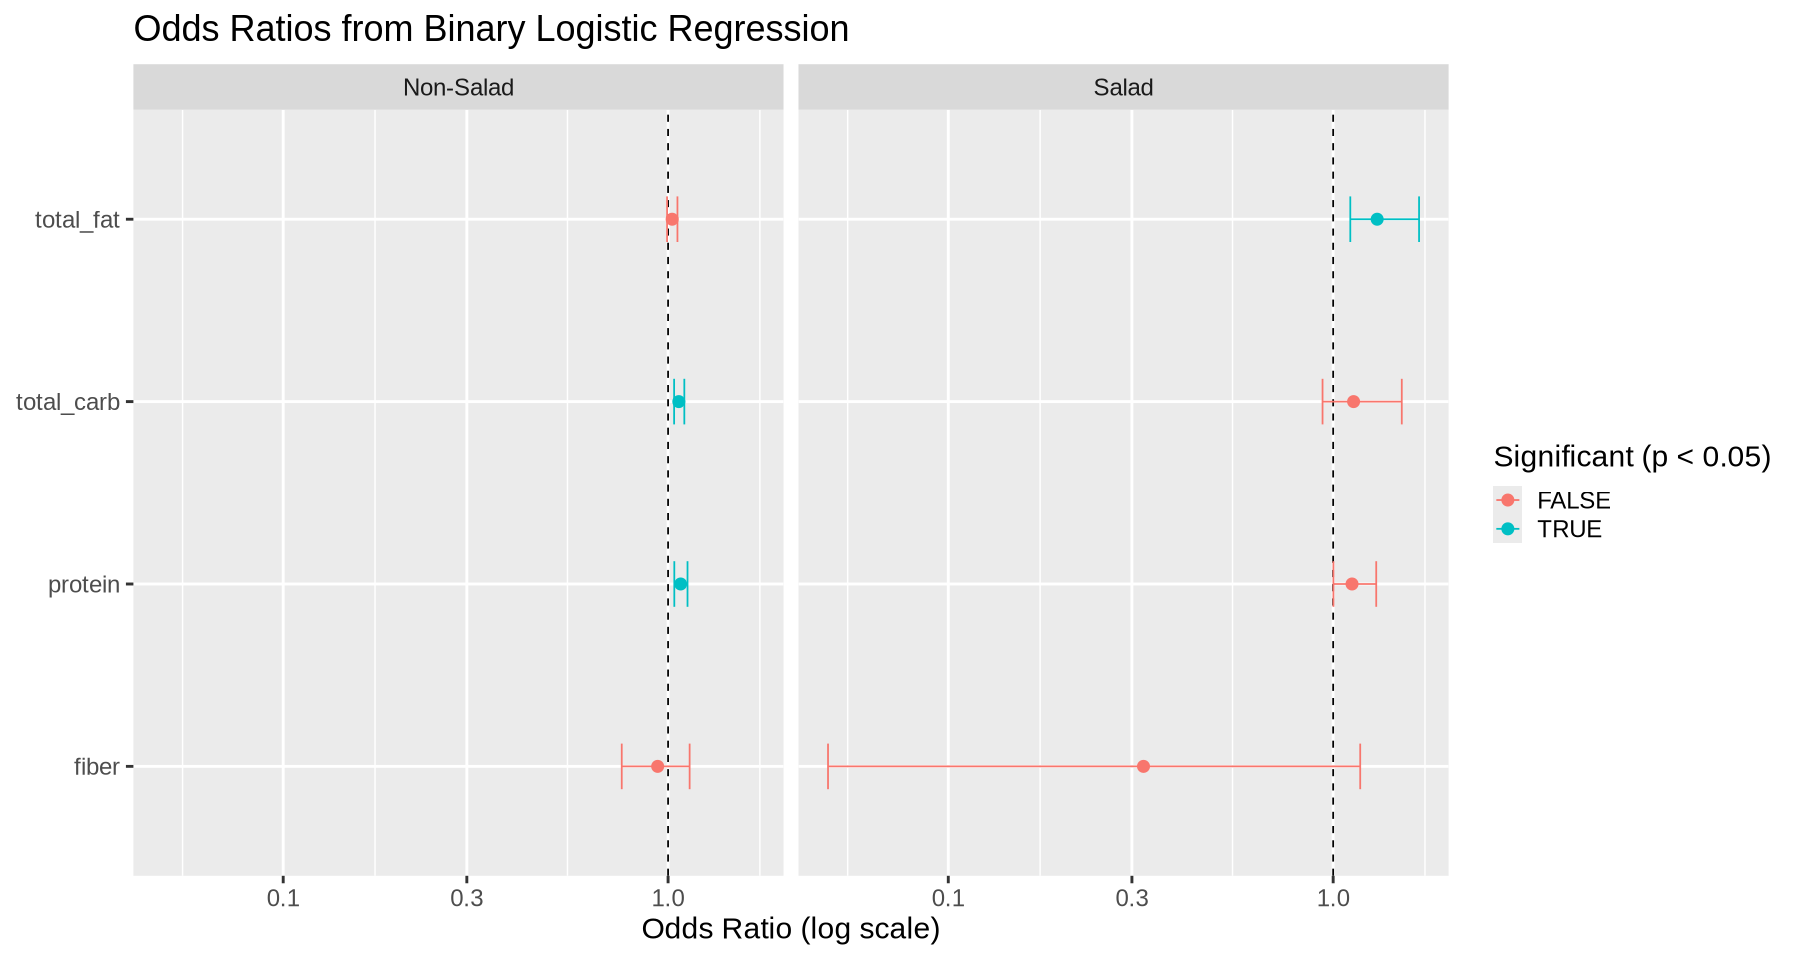

In [16]:
options(repr.plot.width=15, repr.plot.height=8)

or_nonsalad <- broom::tidy(model_nonsalad, conf.int = TRUE, exponentiate = TRUE) |>
  filter(term != "(Intercept)") |>
  mutate(Model = "Non-Salad")

or_salad <- broom::tidy(model_salad, conf.int = TRUE, exponentiate = TRUE) |>
  filter(term != "(Intercept)") |>
  mutate(Model = "Salad")

plot_data <- bind_rows(or_nonsalad, or_salad) |>
  mutate(significant = p.value < 0.05)

ggplot(plot_data, aes(
  x = estimate,
  y = term, 
  xmin = conf.low, 
  xmax = conf.high, 
  colour = significant)) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  geom_errorbarh(height = 0.25) +
  geom_point(size = 3) +
  facet_wrap(~ Model) +
  scale_x_log10() +
  labs(
    title = "Odds Ratios from Binary Logistic Regression ",
    x = "Odds Ratio (log scale)",
    y = NULL,
    colour = "Significant (p < 0.05)") +
  theme_grey(base_size = 18)

### Interpretation

- Both logistic regression models identify specific nutrients associated with higher odds of an item being classified as high in sodium, with protein and total carbohydrates significant in non-salad items and total fat significant in salad items.
- The narrow confidence intervals for these significant predictors suggest the estimates are stable and meaningfully address the question of which macronutrients are linked to high sodium content.
- However, the very wide confidence intervals for fiber in both models indicate substantial uncertainty, likely due to limited variation in fiber values across items. This tells us that the relationship between fiber and high sodium classification cannot be interpreted reliably.
- The divergence in significant predictors between the two models further suggests that the macronutrient drivers of high sodium differ between salad and non-salad items, which supports the decision to fit separate models rather than a single pooled model.

### AI Tool Disclosure

Claude (Anthropic) was used as an AI assistant in this section. Specifically, it was used to provide suggestions to improve the visual formatting of the ggplot figure and theme adjustments to enhance overall readability. It was also used to improve the formatting and structure of Markdown cells within the notebook. 

All analytical decisions, code logic, and written interpretations are my own.

In [17]:
## 3d) Code
## LASSO logistic regression 
library(glmnet)
library(broom)
library(dplyr)
library(ggplot2)
library(car)


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




In [35]:
#LASSO for the non-salad model 
y_nonsalad <- ifelse(df_nonsalad$high_sodium == "High", 1, 0)

X_nonsalad <- model.matrix(
  high_sodium ~ total_fat + total_carb + protein + fiber,
  data = df_nonsalad
)[, -1]

cv_lasso_nonsalad <- cv.glmnet(
  X_nonsalad, y_nonsalad,
  family = "binomial",
  alpha = 1
)

coef_nonsalad <- coef(cv_lasso_nonsalad, s = "lambda.min")

selected_nonsalad <- rownames(coef_nonsalad)[as.vector(coef_nonsalad != 0)]

selected_nonsalad <- setdiff(selected_nonsalad, "(Intercept)")
print(selected_nonsalad)

[1] "total_fat"  "total_carb" "protein"   


The non salad model selected variables that are strongly associated with the total sodium content. Our final model for non-salad will include "total_fat", "total_carb", "protein" as the predictor variables. This intuitively makes sense as foods rich in carbohydrates and fat are prepared with processed sauces and fried food (salad dressings) which have high sodium. Processed meat is high in sodium content as well.

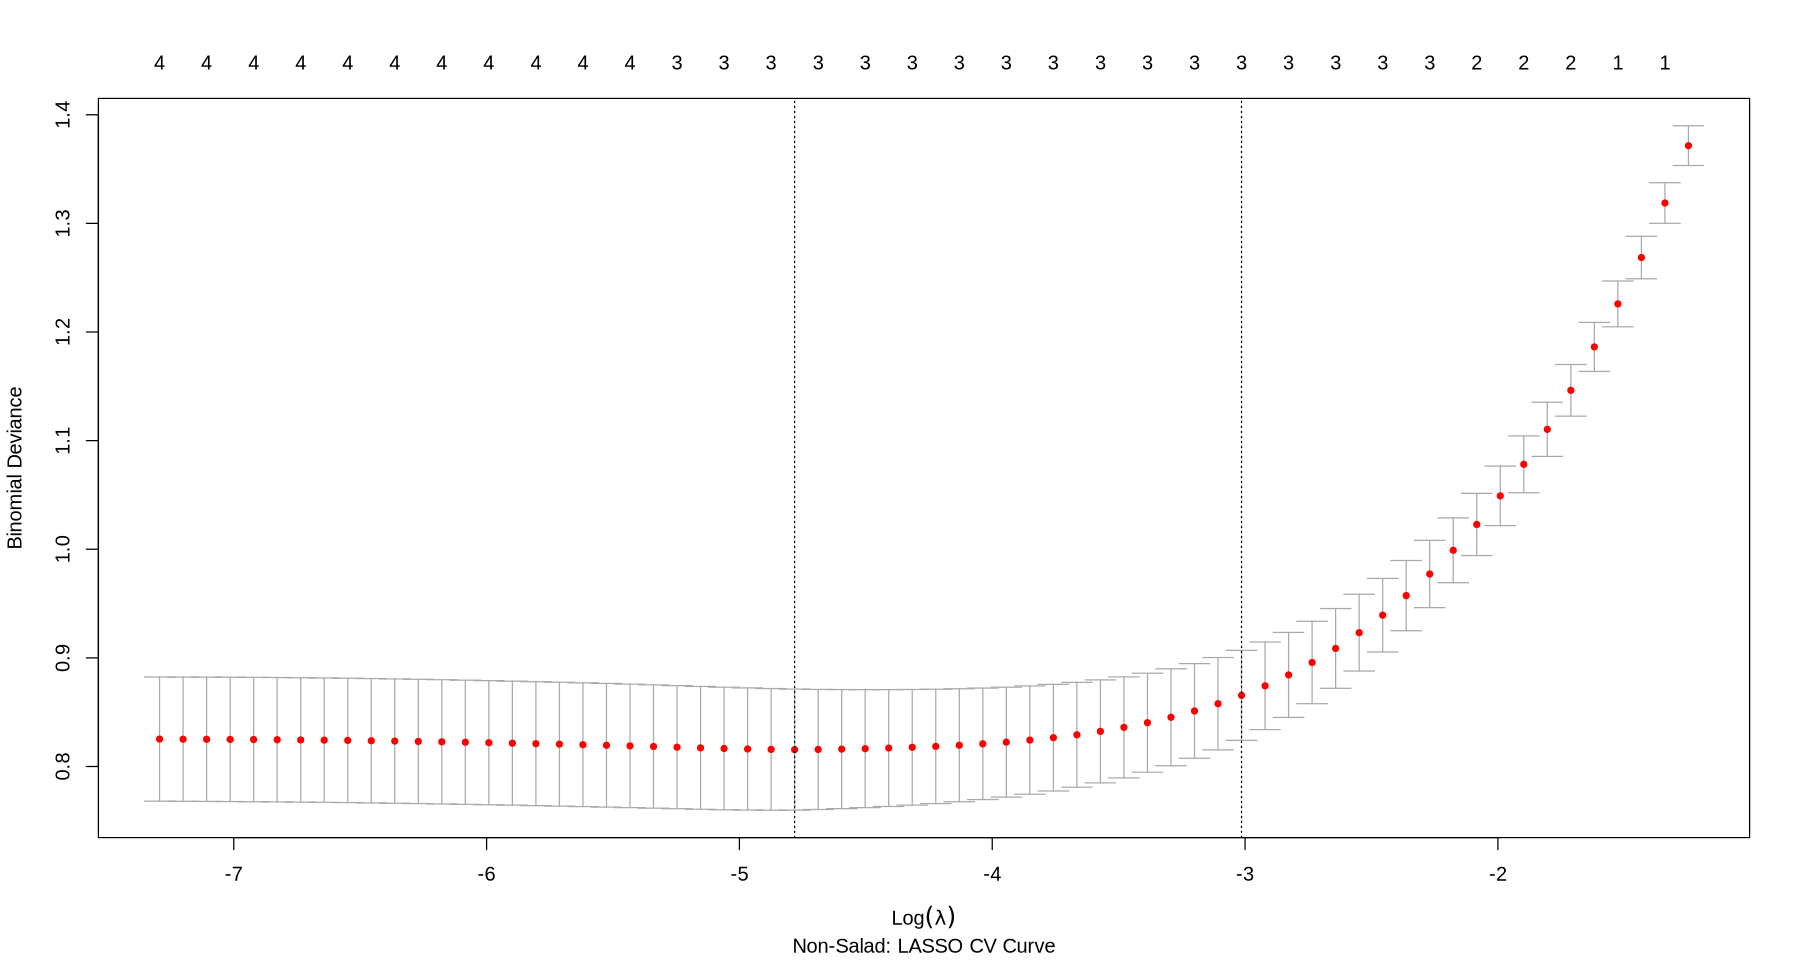

In [28]:
plot(cv_lasso_nonsalad)
title(sub = "Non-Salad: LASSO CV Curve")

The CV LASSO curve for the non-salad model shows that a moderate level of regularization minimizes the cross-validated prediction error. The optimal penalty parameter, λ_min corresponds to the lowest point on the curve and selects a parsimonious set of predictors.At this value of λ, the LASSO model retains three key variables: total_fat, total_carb, and protein.

In [29]:
#Model used in non-salad model 
final_nonsalad <- glm(
  high_sodium ~ total_fat + total_carb + protein,
  data = df_nonsalad,
  family = binomial
)

summary(final_nonsalad)
exp(coef(final_nonsalad))


Call:
glm(formula = high_sodium ~ total_fat + total_carb + protein, 
    family = binomial, data = df_nonsalad)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -6.28603    0.76688  -8.197 2.47e-16 ***
total_fat    0.02713    0.01509   1.797 0.072300 .  
total_carb   0.05773    0.01082   5.336 9.50e-08 ***
protein      0.07533    0.02001   3.765 0.000167 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 356.56  on 260  degrees of freedom
Residual deviance: 203.66  on 257  degrees of freedom
AIC: 211.66

Number of Fisher Scoring iterations: 6


(Intercept)   total_fat  total_carb     protein 
0.001862146 1.027496591 1.059429092 1.078239192

At α = 0.05 total_carb and protein are statistically significant predictors in the model, as their p-values are less than 0.05. In contrast, total_fat is not statistically significant at this level 
(p=0.07), indicating weaker evidence of association with the response.

In [31]:
#lasso for salad model 
y_salad <- ifelse(df_salad$high_sodium == "High", 1, 0)

X_salad <- model.matrix(
  high_sodium ~ total_fat + total_carb + protein + fiber,
  data = df_salad
)[, -1]

cv_lasso_salad <- cv.glmnet(
  X_salad, y_salad,
  family = "binomial",
  alpha = 1
)
coef_salad <- coef(cv_lasso_salad, s = "lambda.min")
coef_salad

selected_salad <- rownames(coef_salad)[as.vector(coef_salad != 0)]
selected_salad <- setdiff(selected_salad, "(Intercept)")

print(selected_salad)

5 x 1 sparse Matrix of class "dgCMatrix"
                     s1
(Intercept) -2.73480527
total_fat    0.13301076
total_carb   .         
protein      0.05981305
fiber        .         

[1] "total_fat" "protein"  


For the salad model,LASSO selected total_fat and protein as the predictors most strongly associated with sodium content.This selection is intuitive. Total fat reflects the use of dressings, oils, and toppings, which are often high in sodium. Protein captures components such as processed or seasoned meats and protein-rich toppings that contain added salt.

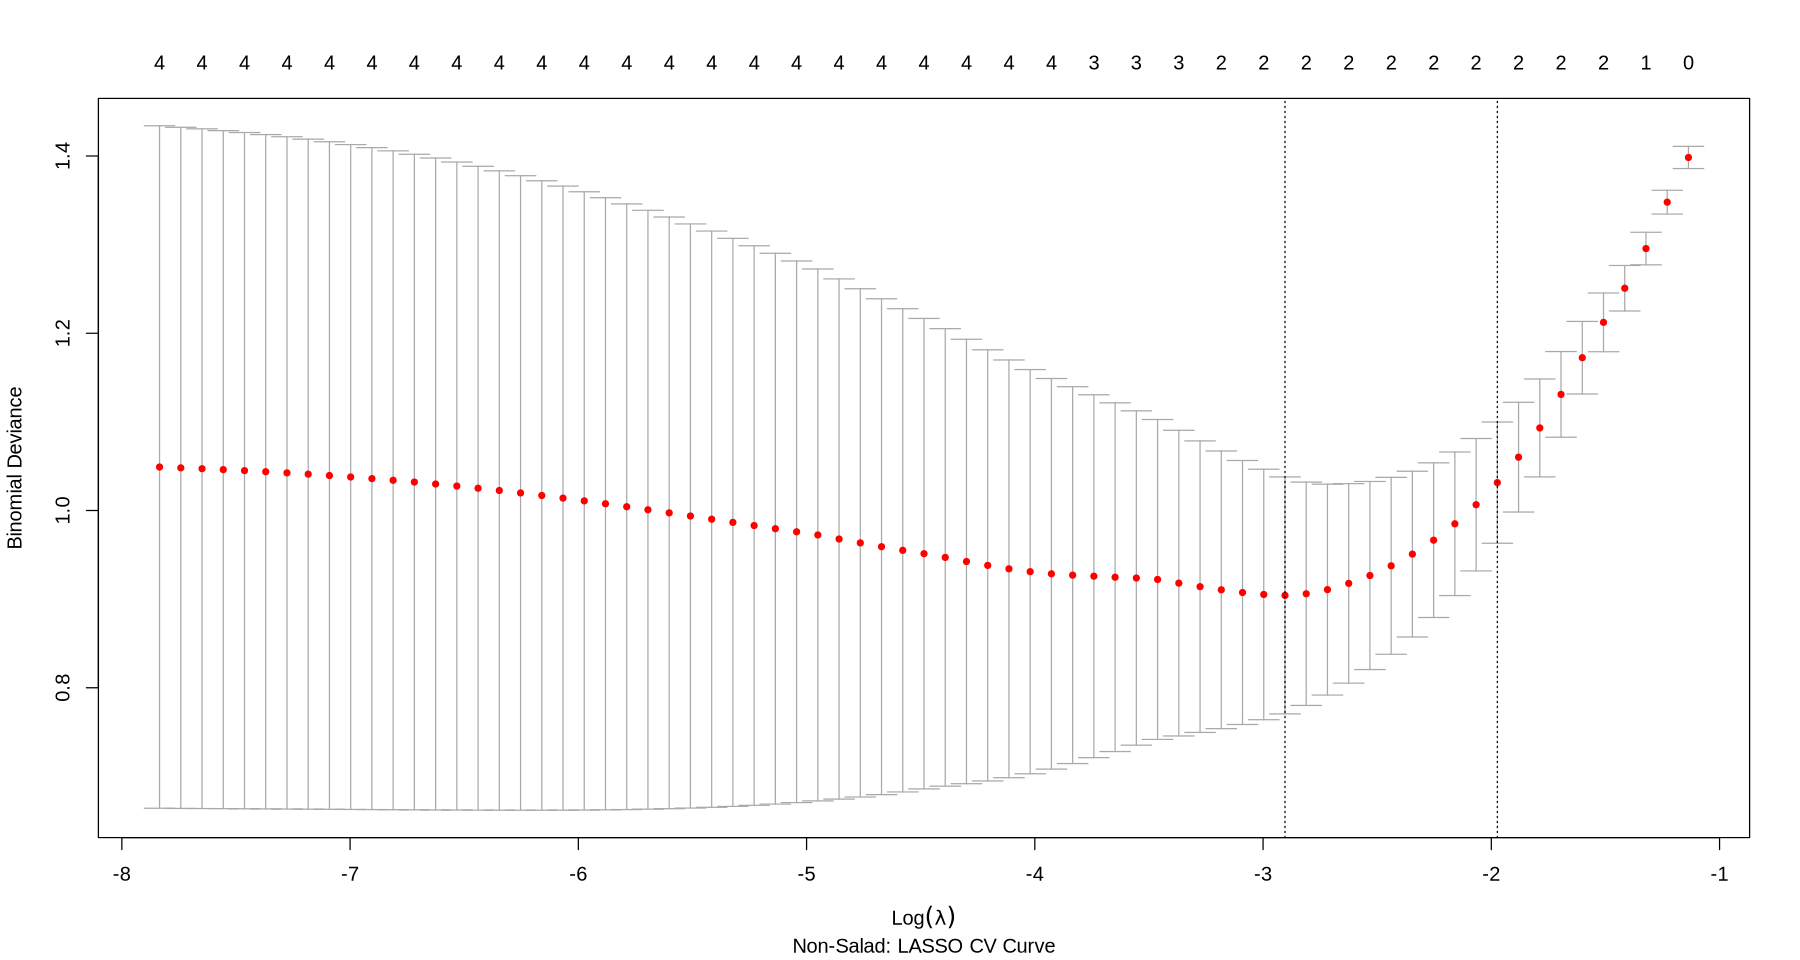

In [32]:
plot(cv_lasso_salad)
title(sub = "Non-Salad: LASSO CV Curve")

The CV LASSO curve for the salad model shows that a moderate level of regularization minimizes the cross-validated prediction error. The optimal penalty parameter, λ_min gives a model that retains three variables: total_fat, protein, and fiber.

In [34]:
#model to use 
final_salad <- glm(
  high_sodium ~ total_fat + protein,
  data = df_salad,
  family = binomial
)


summary(final_salad)
exp(coef(final_salad))


Call:
glm(formula = high_sodium ~ total_fat + protein, family = binomial, 
    data = df_salad)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)   
(Intercept) -4.70448    1.54851  -3.038  0.00238 **
total_fat    0.23439    0.08818   2.658  0.00786 **
protein      0.10361    0.05686   1.822  0.06843 . 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 55.352  on 39  degrees of freedom
Residual deviance: 27.975  on 37  degrees of freedom
AIC: 33.975

Number of Fisher Scoring iterations: 6


(Intercept)   total_fat     protein 
0.009054636 1.264142014 1.109173018

At α = 0.05 total_fat is a statistically significant predictor in the model as its p-value is less than 0.05. In contrast, protein is not statistically significant at this level (p=0.06843), indicating weaker evidence of association with the response.

## RESULTS

### LASSO Variable Selection

The variables selected using LASSO logistic regression were:

- **Non-salad model:** total_fat, total_carb, protein  
- **Salad model:** total_fat, protein  

This indicates that fiber was not retained in the salad model after regularization.



### Final Logistic Regression Models

The final models were fit using binary logistic regression.

#### Non-salad model

\[
\log\left(\frac{p}{1-p}\right)
=
-6.28603
+ 0.02713(\text{total\_fat})
+ 0.05773(\text{total\_carb})
+ 0.07533(\text{protein})
\]

#### Salad model

\[
\log\left(\frac{p}{1-p}\right)
=
-4.70448
+ 0.23439(\text{total\_fat})
+ 0.10361(\text{protein})
\]

where \(p\) is the probability that an item is classified as high sodium.



### Interpretation of Coefficients

#### Non-salad model

- **Intercept (\(\hat{\beta}_0 = -6.28603\))**:  
  Represents the log-odds of a non-salad item being classified as high sodium when all predictors are 0. The corresponding odds are \(e^{-6.28603} \approx 0.0019\), indicating a very low baseline probability.

- **Total fat (\(\hat{\beta}_1 = 0.02713\))**:  
  A one-unit increase in total fat is associated with an increase of 0.02713 in the log-odds of being high sodium, holding other variables constant.  
  The odds ratio is \(e^{0.02713} = 1.0275\), meaning a **2.75% increase in the odds** of being classified as high sodium per unit increase in fat.  
  This predictor is **not statistically significant** (\(p = 0.0723\)), so there is insufficient evidence to conclude a meaningful association.

- **Total carbohydrates (\(\hat{\beta}_2 = 0.05773\))**:  
  A one-unit increase in total carbohydrates increases the log-odds by 0.05773.  
  The odds ratio is \(e^{0.05773} = 1.0594\), indicating a **5.94% increase in odds** per unit increase.  
  This predictor is **highly statistically significant** (\(p < 0.001\)), providing strong evidence of association.

- **Protein (\(\hat{\beta}_3 = 0.07533\))**:  
  A one-unit increase in protein increases the log-odds by 0.07533.  
  The odds ratio is \(e^{0.07533} = 1.0782\), corresponding to a **7.82% increase in odds** per unit increase.  
  This predictor is **statistically significant** (\(p < 0.001\)).

At the 5% significance level:
- Significant: total_carb, protein  
- Not significant: total_fat  


#### Salad model

- **Intercept (\(\hat{\beta}_0 = -4.70448\))**:  
  Represents the baseline log-odds of a salad item being classified as high sodium when predictors are 0. The corresponding odds are \(e^{-4.70448} \approx 0.0091\), indicating a low baseline probability.

- **Total fat (\(\hat{\beta}_1 = 0.23439\))**:  
  A one-unit increase in total fat increases the log-odds by 0.23439.  
  The odds ratio is \(e^{0.23439} = 1.2641\), indicating a **26.41% increase in the odds** of being classified as high sodium per unit increase.  
  This predictor is **statistically significant** (\(p = 0.00786\)).

- **Protein (\(\hat{\beta}_2 = 0.10361\))**:  
  A one-unit increase in protein increases the log-odds by 0.10361.  
  The odds ratio is \(e^{0.10361} = 1.1092\), corresponding to a **10.92% increase in odds** per unit increase.  
  This predictor is **marginally significant** (\(p = 0.0684\)), indicating weaker evidence at the 5% level.

At the 5% significance level:
- Significant: total_fat  
- Marginal: protein  



### Model Fit

#### Non-salad model

- Null deviance: 356.56 (df = 260)  
- Residual deviance: 203.66 (df = 257)  
- AIC: 211.66  

The large reduction in deviance indicates that the predictors substantially improve model fit compared to the intercept-only model.


#### Salad model

- Null deviance: 55.352 (df = 39)  
- Residual deviance: 27.975 (df = 37)  
- AIC: 33.975  

Again, the reduction in deviance suggests that the model provides a good fit relative to the null model.


### Hypothesis Testing

For each predictor:

\[
H_0: \beta_j = 0 \quad \text{vs} \quad H_1: \beta_j \neq 0
\]

At the 5% significance level:

- **Non-salad model:** total_carb and protein are significant predictors  
- **Salad model:** total_fat is significant, while protein shows marginal significance  



### Model Comparison

The LASSO-selected models are more selective than the full models, retaining only the most relevant predictors.

- Protein is important across both models  
- Carbohydrates are key for non-salad items  
- Fat plays a stronger role in salad items  

### Conclusion

Macronutrient composition is associated with whether an item is classified as high sodium, with different predictors playing dominant roles across item types.

- For non-salad items, **total carbohydrates and protein** are the strongest predictors  
- For salad items, **total fat** is the strongest predictor, with protein showing weaker evidence  

This supports the use of separate models for salad and non-salad items, as the relationships differ across groups.
